# Decision Tree Classification — IBM Employee Attrition

**Task:** Binary classification — predict whether an employee will leave (`Attrition = 1`) or stay (`Attrition = 0`)  
**Dataset:** IBM HR Analytics (pre-cleaned train/test splits)  
**Challenge:** The dataset is heavily imbalanced — most employees don't leave, which makes recall for the minority class the hardest metric to improve.

**Approach:**
```
1  Baseline DT                    → establish a performance floor
2  Grid Search DT                 → systematic hyperparameter tuning
3  Full Random Oversampling + DT  → 1:1 class balance via random oversampling
4  Pruned Balanced DT             → CCP pruning on top of full oversampling
5  Threshold Optimisation         → find the decision boundary that maximises F1
6  Feature Importance             → what the final model actually relies on
7  Tree Visualisation             → inspect the top-level decision logic
```

---
## Table of Contents
1. [Setup & Data Loading](#1)
2. [Exploratory Checks](#2)
3. [Baseline Decision Tree](#3)
4. [Grid Search Optimisation](#4)
5. [Full Random Oversampling + Pruned DT](#5)
6. [Cost-Complexity Pruning Path](#6)
7. [Threshold Optimisation](#7)
8. [Feature Importance](#8)
9. [Tree Visualisation](#9)
10. [Final Evaluation](#10)
11. [ROC Curve](#11)
12. [Final Model Comparison](#12)
13. [Conclusion](#13)

---
## 1. Setup & Data Loading <a id='1'></a>

All imports in one place — run this cell first.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Standard libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

# Scikit-learn: model & tuning
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV

# Scikit-learn: evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

# Imbalanced-learn: resampling
try:
    from imblearn.over_sampling import RandomOverSampler
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'imbalanced-learn', '-q'])
    from imblearn.over_sampling import RandomOverSampler

In [3]:
# Load pre-cleaned IBM train/test splits
train_df = pd.read_csv("/content/drive/MyDrive/ML DS/train_data_ibm.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/ML DS/test_data_ibm.csv")

print(f"Train : {train_df.shape[0]:,} rows  ×  {train_df.shape[1]} columns")
print(f"Test  : {test_df.shape[0]:,}  rows  ×  {test_df.shape[1]}  columns")

train_df.head(15)

Train : 1,176 rows  ×  44 columns
Test  : 294  rows  ×  44  columns


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,OverTime,...,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,Attrition
0,1.090194,1.049455,-0.899915,4,2,4,4,2,2.026752,0,...,1,0,0,0,0,0,1,0,0,0
1,-1.634828,-0.523449,-0.899915,1,3,3,1,4,-0.864408,0,...,0,0,0,0,0,0,0,1,0,0
2,0.981193,-0.992080,-0.777610,1,1,3,4,3,2.347706,0,...,1,0,0,0,0,0,0,1,0,0
3,-1.307825,-0.453653,0.445433,1,2,3,1,3,-0.956202,0,...,0,0,0,0,0,1,0,1,0,0
4,0.654191,0.491086,-0.043784,5,4,3,2,3,-0.185956,1,...,0,0,0,0,0,0,1,0,0,0
5,-0.980822,0.879950,-0.899915,4,1,1,1,4,-0.662120,1,...,0,0,0,1,0,0,0,1,0,1
6,1.526197,0.072310,-1.022219,3,3,3,1,4,-0.821414,0,...,0,0,0,1,0,0,0,1,0,0
7,0.654191,0.692996,2.157694,3,3,3,3,1,0.919216,0,...,0,1,0,0,0,0,0,1,0,0
8,0.327188,-1.709982,0.567738,2,4,3,2,1,-0.409527,0,...,0,0,0,0,1,0,0,1,0,0
9,-1.089823,-1.493116,0.078520,3,4,2,2,4,-0.166609,1,...,0,0,0,0,1,0,0,1,0,0


In [4]:
# Separate features (X) from the target (y)
TARGET  = 'Attrition'

X_train = train_df.drop(TARGET, axis=1)
y_train = train_df[TARGET]

X_test  = test_df.drop(TARGET, axis=1)
y_test  = test_df[TARGET]

print(f"X_train : {X_train.shape}   |   X_test : {X_test.shape}")
print(f"Features: {list(X_train.columns[:5])} ... (first 5 shown)")

X_train : (1176, 43)   |   X_test : (294, 43)
Features: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction'] ... (first 5 shown)


In [5]:
# Shared helpers used throughout

def print_metrics(y_true, y_pred, y_prob, title):
    """Print accuracy, precision, recall, F1 and ROC-AUC in a consistent block."""
    print(f"\n{'='*58}")
    print(f"  {title}")
    print(f"{'='*58}")
    print(f"  Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"  F1 Score : {f1_score(y_true, y_pred):.4f}")
    print(f"  ROC-AUC  : {roc_auc_score(y_true, y_prob):.4f}")
    print(f"{'='*58}")
    print()
    print(classification_report(y_true, y_pred, target_names=['Stay (0)', 'Leave (1)']))


def plot_confusion_matrix(y_true, y_pred, title):
    """Plot a labelled confusion matrix heatmap."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Stay (0)', 'Leave (1)'],
                yticklabels=['Stay (0)', 'Leave (1)'])
    plt.title(title, fontweight='bold', fontsize=12)
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout(); plt.show()

---
## 2. Exploratory Checks <a id='2'></a>

Before any modelling, confirm the data is clean and understand the class distribution. Class imbalance is the central challenge in attrition prediction — this chart motivates every design choice that follows.

In [6]:
# Missing value check
print(f"Missing values in X_train: {X_train.isnull().sum().sum()}")
print(f"Missing values in X_test : {X_test.isnull().sum().sum()}")
print(f"\nFeature dtypes:")
print(X_train.dtypes.value_counts())

Missing values in X_train: 0
Missing values in X_test : 0

Feature dtypes:
int64      34
float64     9
Name: count, dtype: int64


Training set class distribution:
  Stay (0): 986  (83.8%)
  Leave (1): 190  (16.2%)


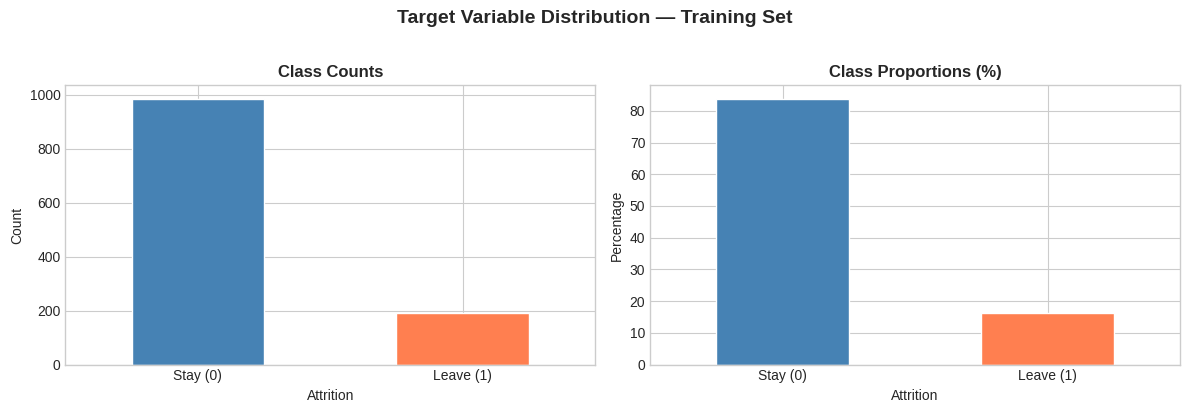

In [7]:
# Target class distribution
# A model that always predicts 'Stay' would score ~85% accuracy on this dataset
# yet catch zero employees who leave. That's why we optimise for F1, not accuracy.
class_counts = y_train.value_counts()
class_pct    = y_train.value_counts(normalize=True) * 100

print("Training set class distribution:")
for cls in class_counts.index:
    label = 'Leave' if cls == 1 else 'Stay'
    print(f"  {label} ({cls}): {class_counts[cls]:,}  ({class_pct[cls]:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

class_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], edgecolor='white')
axes[0].set_title('Class Counts', fontweight='bold')
axes[0].set_xlabel('Attrition'); axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Stay (0)', 'Leave (1)'], rotation=0)

class_pct.plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'], edgecolor='white')
axes[1].set_title('Class Proportions (%)', fontweight='bold')
axes[1].set_xlabel('Attrition'); axes[1].set_ylabel('Percentage')
axes[1].set_xticklabels(['Stay (0)', 'Leave (1)'], rotation=0)

plt.suptitle('Target Variable Distribution — Training Set', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

In [8]:
# Train vs Test class balance comparison
# Confirms the split preserved the original class ratio
split_balance = pd.DataFrame({
    'Train %': y_train.value_counts(normalize=True).sort_index() * 100,
    'Test %':  y_test.value_counts(normalize=True).sort_index() * 100
})
split_balance.index = ['Stay (0)', 'Leave (1)']
print("Class balance — train vs test:")
print(split_balance.round(2).to_string())

Class balance — train vs test:
           Train %  Test %
Stay (0)     83.84   84.01
Leave (1)    16.16   15.99


---
## 3. Baseline Decision Tree <a id='3'></a>

The baseline uses manually chosen hyperparameters with no class balancing. Its purpose is purely to set a performance floor — every subsequent model must beat it on at least recall for the `Leave` class.

| Parameter | Value | Why |
|---|---|---|
| `criterion` | `gini` | Efficient impurity measure for binary targets |
| `max_depth` | 6 | Shallow enough to avoid memorising noise |
| `min_samples_split` | 10 | A node needs at least 10 samples before it can split |
| `min_samples_leaf` | 5 | Each leaf must represent at least 5 training samples |

In [9]:
# Train and evaluate the baseline
baseline_dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
baseline_dt.fit(X_train, y_train)

y_pred_baseline = baseline_dt.predict(X_test)
y_prob_baseline = baseline_dt.predict_proba(X_test)[:, 1]

print_metrics(y_test, y_pred_baseline, y_prob_baseline, "Baseline Decision Tree")


  Baseline Decision Tree
  Accuracy : 0.8095
  Precision: 0.4000
  Recall   : 0.3830
  F1 Score : 0.3913
  ROC-AUC  : 0.6727

              precision    recall  f1-score   support

    Stay (0)       0.88      0.89      0.89       247
   Leave (1)       0.40      0.38      0.39        47

    accuracy                           0.81       294
   macro avg       0.64      0.64      0.64       294
weighted avg       0.81      0.81      0.81       294



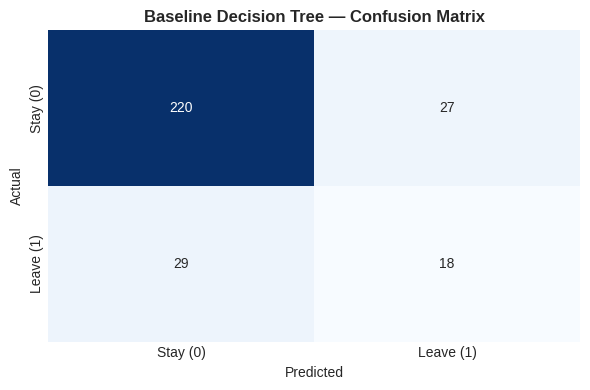

In [10]:
plot_confusion_matrix(y_test, y_pred_baseline, "Baseline Decision Tree — Confusion Matrix")

---
## 4. Grid Search Optimisation <a id='4'></a>

Grid Search exhaustively tests every hyperparameter combination and picks the winner by **F1 score** — the right optimisation target here because F1 penalises both poor recall and poor precision equally, which matters when classes are imbalanced.

`class_weight='balanced'` is included in the grid. This tells sklearn to upweight the minority class inversely proportional to its frequency — a zero-cost way to push recall up without any resampling.

**Search space:** 2 × 5 × 4 × 4 × 2 = **320 combinations** × 5 folds = 1,600 model fits

In [11]:
# Define and run the grid search
param_grid = {
    'criterion':         ['gini', 'entropy'],   # how impurity is measured at each split
    'max_depth':         [4, 6, 8, 10, 12],     # controls tree depth
    'min_samples_split': [2, 5, 10, 20],        # minimum samples to split a node
    'min_samples_leaf':  [1, 2, 5, 10],         # minimum samples at a leaf
    'class_weight':      [None, 'balanced']     # handles class imbalance
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print("Best parameters found:")
for param, val in grid_search.best_params_.items():
    print(f"  {param:25s}: {val}")

Fitting 5 folds for each of 320 candidates, totalling 1600 fits
Best parameters found:
  class_weight             : balanced
  criterion                : gini
  max_depth                : 4
  min_samples_leaf         : 2
  min_samples_split        : 2


In [12]:
# Evaluate the winner
grid_dt     = grid_search.best_estimator_
y_pred_grid = grid_dt.predict(X_test)
y_prob_grid = grid_dt.predict_proba(X_test)[:, 1]

print_metrics(y_test, y_pred_grid, y_prob_grid, "Grid Search Decision Tree")


  Grid Search Decision Tree
  Accuracy : 0.7789
  Precision: 0.3676
  Recall   : 0.5319
  F1 Score : 0.4348
  ROC-AUC  : 0.6538

              precision    recall  f1-score   support

    Stay (0)       0.90      0.83      0.86       247
   Leave (1)       0.37      0.53      0.43        47

    accuracy                           0.78       294
   macro avg       0.64      0.68      0.65       294
weighted avg       0.82      0.78      0.79       294



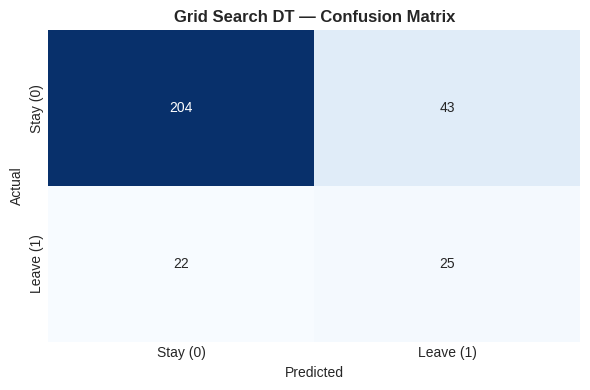

In [13]:
plot_confusion_matrix(y_test, y_pred_grid, "Grid Search DT — Confusion Matrix")

---
## 5. Full Random Oversampling + Pruned DT <a id='5'></a>

Full random oversampling (`sampling_strategy=1.0`) duplicates minority-class records until both classes are equal in size. Unlike SMOTE, it doesn't synthesise new samples — it just repeats existing ones, which is safer when features include encoded categoricals.

**Cost-complexity pruning** (`ccp_alpha=0.005`) is applied on top to counteract a known side effect of oversampling: the model can overfit to the duplicated records. Pruning removes branches that contribute less than 0.5% accuracy improvement, producing a simpler, more generalisable tree.

> Oversampling is applied only to the **training set**. The test set stays untouched — it must reflect the real-world class distribution.

In [14]:
# Apply full 1:1 oversampling to the training set only
ros_full = RandomOverSampler(sampling_strategy=1.0, random_state=42)
X_train_full, y_train_full = ros_full.fit_resample(X_train, y_train)

y_full_series = pd.Series(y_train_full)
print("Class distribution after full oversampling:")
print(f"  Stay (0) : {(y_full_series == 0).sum():,}")
print(f"  Leave (1): {(y_full_series == 1).sum():,}")

Class distribution after full oversampling:
  Stay (0) : 986
  Leave (1): 986


In [15]:
# Train the pruned model on the balanced data
pruned_full_dt = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=6,
    min_samples_split=15,
    min_samples_leaf=6,
    ccp_alpha=0.005,          # prunes branches adding < 0.5% accuracy gain
    random_state=42
)
pruned_full_dt.fit(X_train_full, y_train_full)

# Probability scores — needed for threshold optimisation and ROC curve
y_prob_pruned_full = pruned_full_dt.predict_proba(X_test)[:, 1]

# Hard predictions at default threshold (0.50) for reference
y_pred_pruned_default = (y_prob_pruned_full >= 0.50).astype(int)

print_metrics(y_test, y_pred_pruned_default, y_prob_pruned_full,
              "Pruned + Full Oversampling DT (default threshold = 0.50)")


  Pruned + Full Oversampling DT (default threshold = 0.50)
  Accuracy : 0.7449
  Precision: 0.3571
  Recall   : 0.7447
  F1 Score : 0.4828
  ROC-AUC  : 0.7367

              precision    recall  f1-score   support

    Stay (0)       0.94      0.74      0.83       247
   Leave (1)       0.36      0.74      0.48        47

    accuracy                           0.74       294
   macro avg       0.65      0.74      0.66       294
weighted avg       0.85      0.74      0.78       294



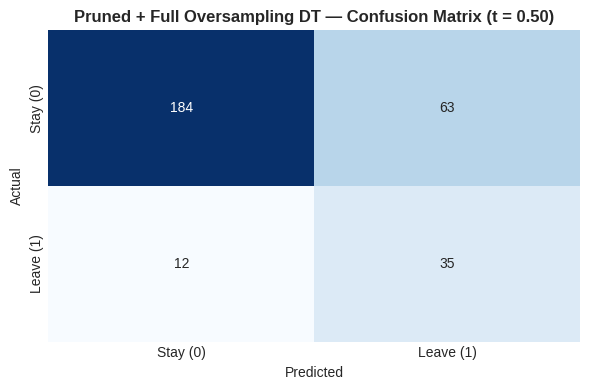

In [16]:
plot_confusion_matrix(y_test, y_pred_pruned_default,
                      "Pruned + Full Oversampling DT — Confusion Matrix (t = 0.50)")

---
## 6. Cost-Complexity Pruning Path <a id='6'></a>

The `ccp_alpha=0.005` used above was chosen manually. This section sweeps the full pruning path to confirm that value sits in the right region — and shows how aggressively pruning affects both accuracy and F1.

- **X-axis:** `ccp_alpha` — higher = more branches removed = simpler tree  
- **Red line:** the alpha used in our pruned model above  
- **What to look for:** the point where F1 starts declining sharply — that's where pruning has gone too far

In [17]:
# Compute the full pruning path from the oversampled training data
pruning_path = pruned_full_dt.cost_complexity_pruning_path(X_train_full, y_train_full)
ccp_alphas   = pruning_path.ccp_alphas

print(f"Pruning path: {len(ccp_alphas)} alpha values")
print(f"Range: {ccp_alphas.min():.8f}  →  {ccp_alphas.max():.6f}")

Pruning path: 30 alpha values
Range: 0.00000000  →  0.066641


In [18]:
# Train one tree per alpha, record accuracy and F1
ccp_acc, ccp_f1_scores = [], []

for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        criterion='entropy',
        max_depth=6,
        min_samples_split=15,
        min_samples_leaf=6,
        ccp_alpha=alpha,
        random_state=42
    )
    clf.fit(X_train_full, y_train_full)
    y_p = clf.predict(X_test)
    ccp_acc.append(accuracy_score(y_test, y_p))
    ccp_f1_scores.append(f1_score(y_test, y_p))

best_ccp_idx   = np.argmax(ccp_f1_scores)
best_ccp_alpha = ccp_alphas[best_ccp_idx]
print(f"Best alpha from sweep: {best_ccp_alpha:.6f}  (F1 = {ccp_f1_scores[best_ccp_idx]:.4f})")

Best alpha from sweep: 0.004837  (F1 = 0.4828)


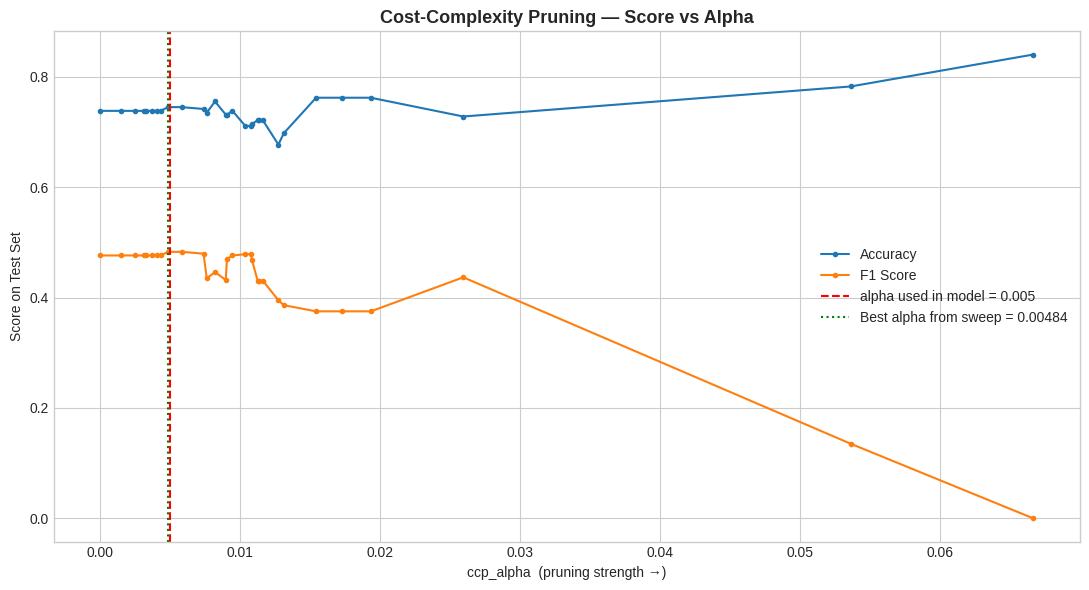

In [19]:
# Plot score vs alpha
plt.figure(figsize=(11, 6))
plt.plot(ccp_alphas, ccp_acc,        marker='o', markersize=3, label='Accuracy')
plt.plot(ccp_alphas, ccp_f1_scores,  marker='o', markersize=3, label='F1 Score')
plt.axvline(0.005, color='red', linestyle='--', linewidth=1.5,
            label='alpha used in model = 0.005')
plt.axvline(best_ccp_alpha, color='green', linestyle=':', linewidth=1.5,
            label=f'Best alpha from sweep = {best_ccp_alpha:.5f}')
plt.xlabel('ccp_alpha  (pruning strength →)')
plt.ylabel('Score on Test Set')
plt.title('Cost-Complexity Pruning — Score vs Alpha', fontweight='bold', fontsize=13)
plt.legend()
plt.tight_layout(); plt.show()

---
## 7. Threshold Optimisation <a id='7'></a>

The default prediction threshold of 0.50 assumes false positives and false negatives are equally costly. In an attrition context, that's rarely true — **missing someone who is about to leave is more expensive** than flagging someone who would have stayed. Unnecessary retention actions are cheap; losing a key employee undetected is not.

Lowering the threshold makes the model more aggressive at predicting `Leave`, trading some precision for better recall. The sweep below finds the threshold that maximises F1 — the best single-number balance between the two.

In [20]:
# Sweep thresholds and record all four metrics at each point
thresholds    = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65]
sweep_results = []

for t in thresholds:
    y_t = (y_prob_pruned_full >= t).astype(int)
    sweep_results.append({
        'threshold': t,
        'accuracy':  accuracy_score(y_test, y_t),
        'precision': precision_score(y_test, y_t),
        'recall':    recall_score(y_test, y_t),
        'f1':        f1_score(y_test, y_t)
    })

sweep_df = pd.DataFrame(sweep_results)
print("Threshold sweep results:")
print(sweep_df.to_string(index=False))

# Derived dynamically — never hardcoded
best_threshold = sweep_df.loc[sweep_df['f1'].idxmax(), 'threshold']
print(f"\nBest threshold: {best_threshold}   (F1 = {sweep_df['f1'].max():.4f})")

Threshold sweep results:
 threshold  accuracy  precision   recall       f1
      0.20  0.428571   0.195980 0.829787 0.317073
      0.25  0.639456   0.284672 0.829787 0.423913
      0.30  0.744898   0.357143 0.744681 0.482759
      0.35  0.744898   0.357143 0.744681 0.482759
      0.40  0.744898   0.357143 0.744681 0.482759
      0.45  0.744898   0.357143 0.744681 0.482759
      0.50  0.744898   0.357143 0.744681 0.482759
      0.55  0.789116   0.397260 0.617021 0.483333
      0.60  0.782313   0.369231 0.510638 0.428571
      0.65  0.775510   0.349206 0.468085 0.400000

Best threshold: 0.55   (F1 = 0.4833)


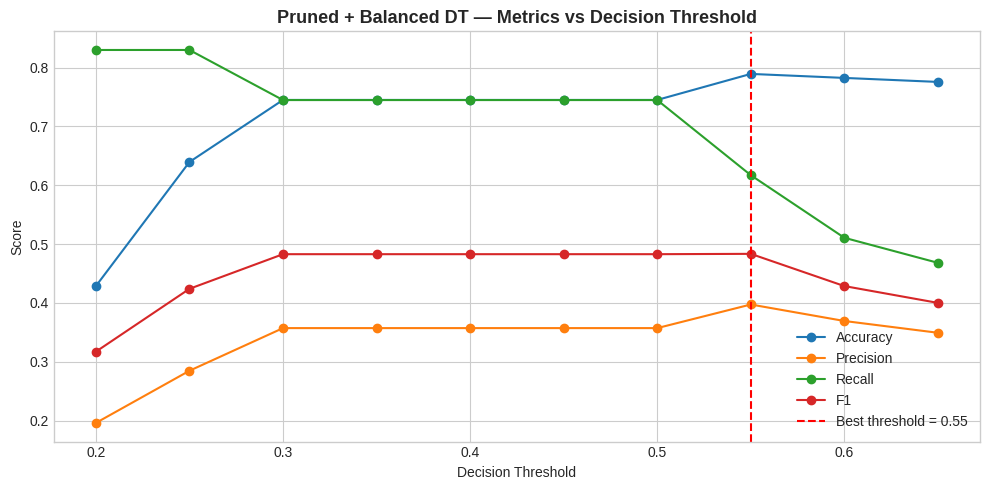

In [21]:
# Visualise the precision-recall tradeoff across thresholds
# As threshold drops, recall rises and precision falls — the red line shows where F1 peaks
plt.figure(figsize=(10, 5))
for metric in ['accuracy', 'precision', 'recall', 'f1']:
    plt.plot(sweep_df['threshold'], sweep_df[metric], marker='o', label=metric.capitalize())

plt.axvline(best_threshold, color='red', linestyle='--', linewidth=1.5,
            label=f'Best threshold = {best_threshold}')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Pruned + Balanced DT — Metrics vs Decision Threshold', fontweight='bold', fontsize=13)
plt.legend()
plt.tight_layout(); plt.show()

---
## 8. Feature Importance <a id='8'></a>

Decision trees record how much each feature reduces **Gini impurity** across all splits in the tree. Normalised to sum to 1, this gives an importance score per feature — higher means the model relies on that feature more heavily to separate the classes.

All importance scores are drawn from **`pruned_full_dt`** — the final model, not any intermediate experiment.

> **Limitation worth noting:** Gini importance can overstate the influence of high-cardinality features (those with many unique values). SHAP values would give a more reliable attribution if this analysis were taken further.

In [22]:
# Extract importances from the final model
importance_df = (
    pd.DataFrame({
        'Feature':    X_train.columns,
        'Importance': pruned_full_dt.feature_importances_
    })
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

print("Top 20 features by Gini importance (Final Model):")
print(importance_df.head(20).to_string(index=False))

Top 20 features by Gini importance (Final Model):
                   Feature  Importance
         TotalWorkingYears    0.174526
                  OverTime    0.163817
                       Age    0.119484
           JobSatisfaction    0.102908
             MonthlyIncome    0.080975
JobRole_Research Scientist    0.074363
          StockOptionLevel    0.073614
                 DailyRate    0.056665
           WorkLifeBalance    0.053373
  RelationshipSatisfaction    0.033296
          DistanceFromHome    0.027095
            JobInvolvement    0.024702
     MaritalStatus_Married    0.015183
   EnvironmentSatisfaction    0.000000
                  JobLevel    0.000000
         PerformanceRating    0.000000
                 Education    0.000000
     TrainingTimesLastYear    0.000000
            YearsAtCompany    0.000000
 BusinessTravel_Non-Travel    0.000000


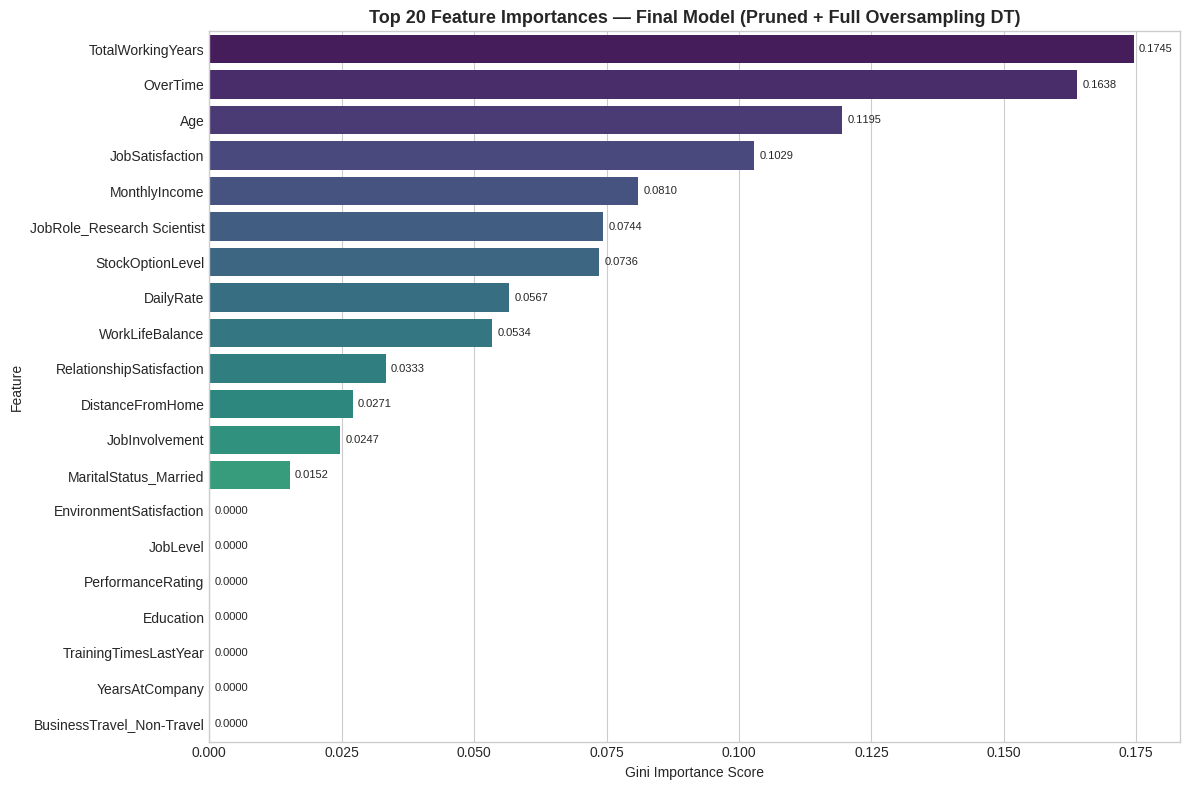

In [23]:
# Horizontal bar chart — top 20 features
top20 = importance_df.head(20)

plt.figure(figsize=(12, 8))
ax = sns.barplot(data=top20, x='Importance', y='Feature', palette='viridis')

# Label each bar with its exact score
for bar, val in zip(ax.patches, top20['Importance']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=8)

plt.title('Top 20 Feature Importances — Final Model (Pruned + Full Oversampling DT)',
          fontsize=13, fontweight='bold')
plt.xlabel('Gini Importance Score')
plt.ylabel('Feature')
plt.tight_layout(); plt.show()

---
## 9. Tree Visualisation <a id='9'></a>

Visualising the first 3 levels of the tree reveals the top-level decision logic — the questions the model asks first when classifying a new employee record.

Each node shows:
- **The feature and threshold being tested**
- **Gini impurity** — how mixed the classes are at that node (0 = pure, 0.5 = maximally mixed)
- **Class proportions** — fraction of samples in each class at that node
- **Node colour** — blue tones for `Stay`, orange for `Leave`; deeper = higher purity

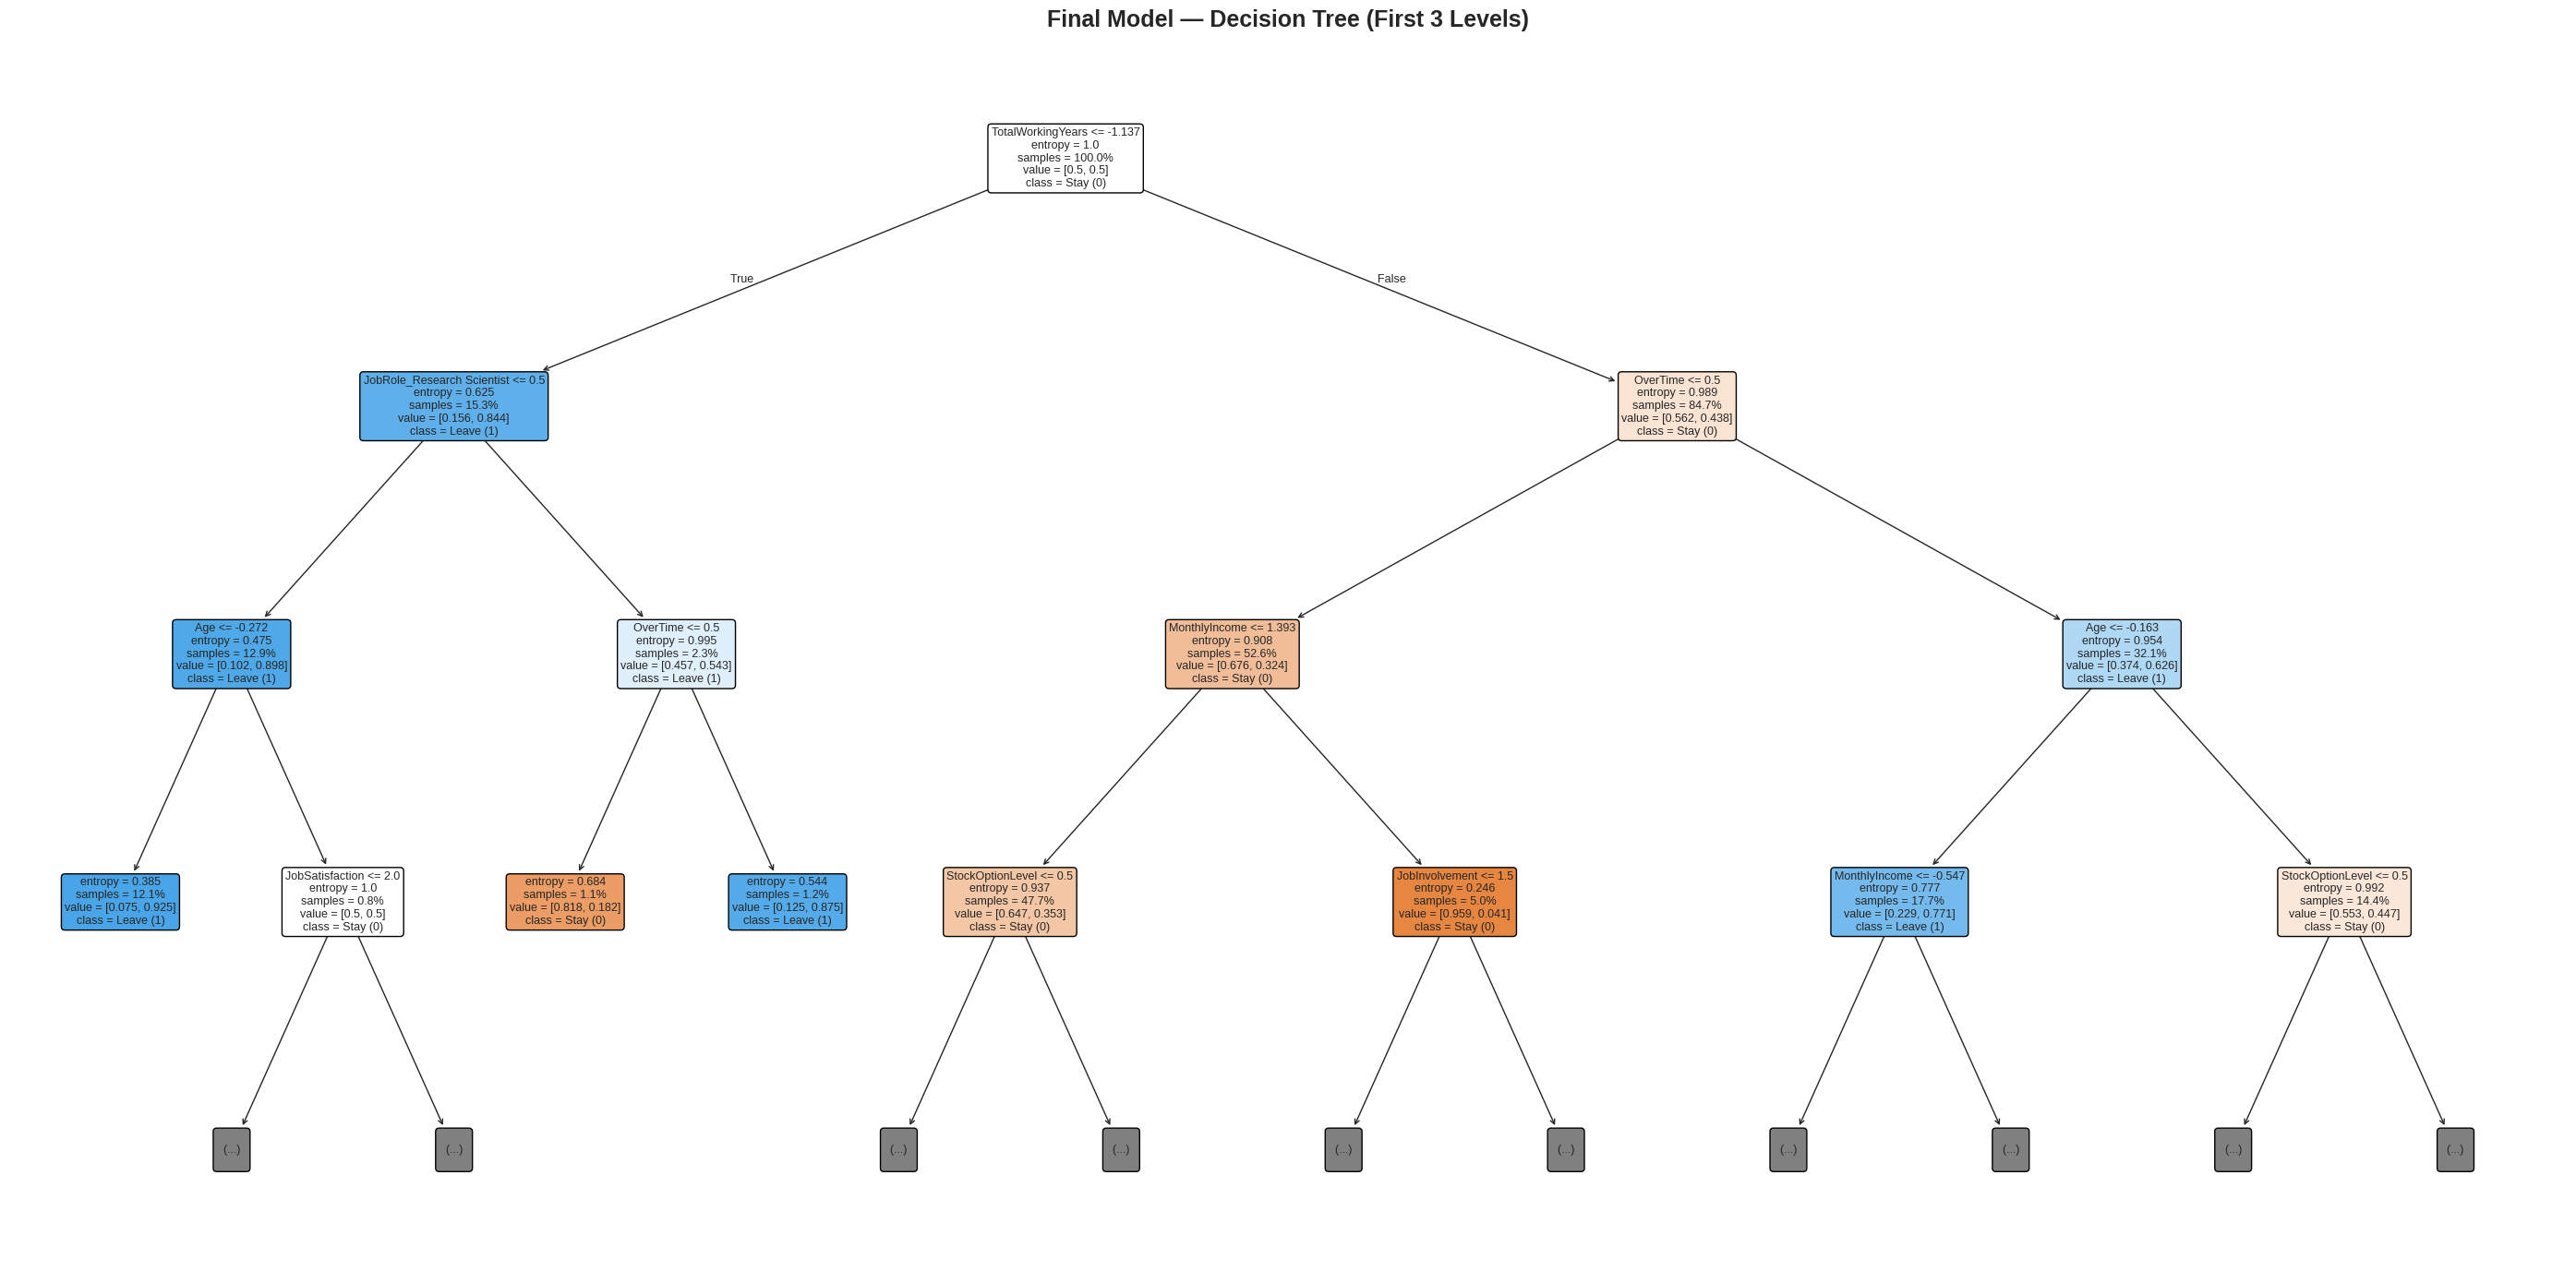

In [24]:
# Plot first 3 levels of the final model
# Deeper levels become unreadable at any reasonable figure size
plt.figure(figsize=(28, 14))
plot_tree(
    pruned_full_dt,
    filled=True,                          # colour nodes by majority class
    feature_names=list(X_train.columns),  # post-encoding feature names
    class_names=['Stay (0)', 'Leave (1)'],
    rounded=True,
    proportion=True,                      # show class proportions, not raw counts
    max_depth=3,                          # first 3 levels only — deeper = unreadable
    fontsize=9
)
plt.title('Final Model — Decision Tree (First 3 Levels)', fontsize=18, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 10. Final Evaluation <a id='10'></a>

The final model is `pruned_full_dt` evaluated at `best_threshold` — derived from the sweep above. This is the authoritative output for all downstream reporting.

In [25]:
# Final predictions at the optimised threshold
y_pred_final = (y_prob_pruned_full >= best_threshold).astype(int)

print_metrics(y_test, y_pred_final, y_prob_pruned_full,
              f"Final Model — Pruned + Full Oversampling DT (threshold = {best_threshold})")


  Final Model — Pruned + Full Oversampling DT (threshold = 0.55)
  Accuracy : 0.7891
  Precision: 0.3973
  Recall   : 0.6170
  F1 Score : 0.4833
  ROC-AUC  : 0.7367

              precision    recall  f1-score   support

    Stay (0)       0.92      0.82      0.87       247
   Leave (1)       0.40      0.62      0.48        47

    accuracy                           0.79       294
   macro avg       0.66      0.72      0.68       294
weighted avg       0.84      0.79      0.81       294



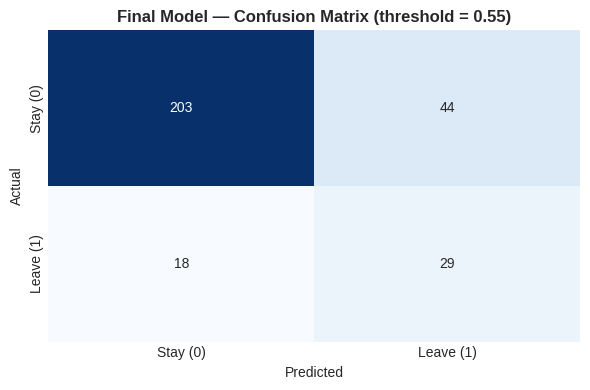

In [26]:
plot_confusion_matrix(
    y_test, y_pred_final,
    f"Final Model — Confusion Matrix (threshold = {best_threshold})"
)

**Reading the confusion matrix:**

| Cell | Meaning |
|---|---|
| Top-left | True Negatives — correctly predicted to stay |
| Top-right | False Positives — predicted to leave, actually stayed |
| Bottom-left | **False Negatives — predicted to stay, actually left** ← the costly error |
| Bottom-right | True Positives — correctly predicted to leave |

---
## 11. ROC Curve <a id='11'></a>

The ROC curve plots True Positive Rate (recall) against False Positive Rate at every possible threshold — a **threshold-independent** view of model performance. AUC summarises it as a single number: higher is better, 0.50 is random guessing.

All three models are overlaid so you can see at a glance which one discriminates best between attritors and non-attritors regardless of threshold choice.

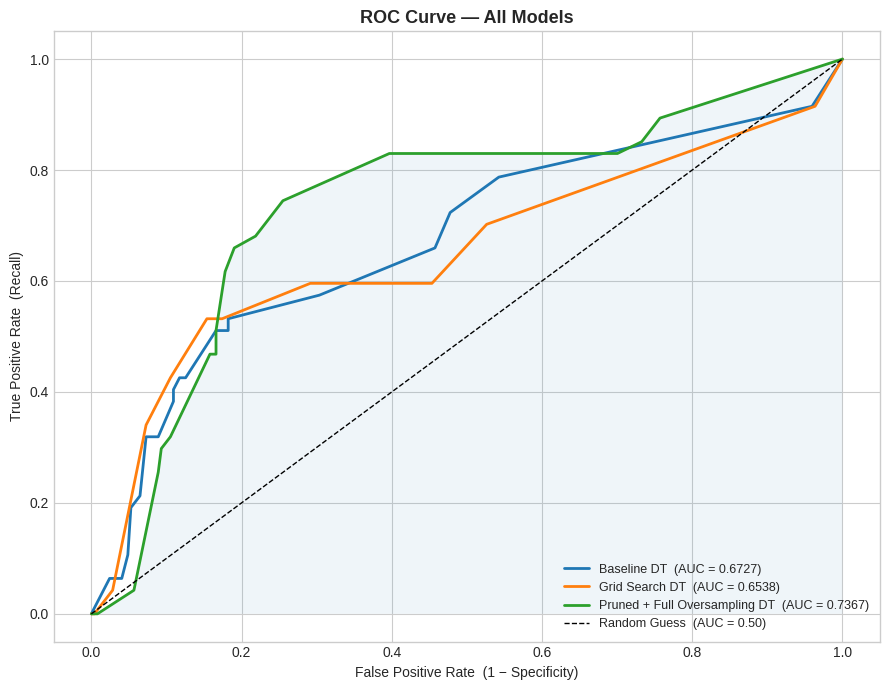

In [27]:
# ROC curves for all three models
roc_models = [
    ('Baseline DT',                   y_prob_baseline),
    ('Grid Search DT',                y_prob_grid),
    ('Pruned + Full Oversampling DT', y_prob_pruned_full),
]

plt.figure(figsize=(9, 7))

for name, y_prob_m in roc_models:
    fpr, tpr, _ = roc_curve(y_test, y_prob_m)
    auc          = roc_auc_score(y_test, y_prob_m)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name}  (AUC = {auc:.4f})')

# Shade area under the final model's curve
fpr_final, tpr_final, _ = roc_curve(y_test, y_prob_pruned_full)
plt.fill_between(fpr_final, tpr_final, alpha=0.07)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess  (AUC = 0.50)')
plt.xlabel('False Positive Rate  (1 − Specificity)')
plt.ylabel('True Positive Rate  (Recall)')
plt.title('ROC Curve — All Models', fontweight='bold', fontsize=13)
plt.legend(fontsize=9, loc='lower right')
plt.tight_layout(); plt.show()

---
## 12. Final Model Comparison <a id='12'></a>

All models on the same test set. Metrics are computed live — retrain any model and this table updates automatically.

In [28]:
# Helper to compute all five metrics in one call
def live_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
        'F1':        round(f1_score(y_true, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_true, y_prob), 4)
    }

# Build comparison table
comparison_df = pd.DataFrame([
    {'Model': 'Baseline DT',
     **live_metrics(y_test, y_pred_baseline, y_prob_baseline)},

    {'Model': 'Grid Search DT',
     **live_metrics(y_test, y_pred_grid, y_prob_grid)},

    {'Model': 'Pruned + Full Oversampling DT (t=0.50)',
     **live_metrics(y_test, y_pred_pruned_default, y_prob_pruned_full)},

    {'Model': f'Final Model — Threshold Optimised (t={best_threshold})',
     **live_metrics(y_test, y_pred_final, y_prob_pruned_full)},
])

print(comparison_df.to_string(index=False))

                                     Model  Accuracy  Precision  Recall     F1  ROC-AUC
                               Baseline DT    0.8095     0.4000  0.3830 0.3913   0.6727
                            Grid Search DT    0.7789     0.3676  0.5319 0.4348   0.6538
    Pruned + Full Oversampling DT (t=0.50)    0.7449     0.3571  0.7447 0.4828   0.7367
Final Model — Threshold Optimised (t=0.55)    0.7891     0.3973  0.6170 0.4833   0.7367


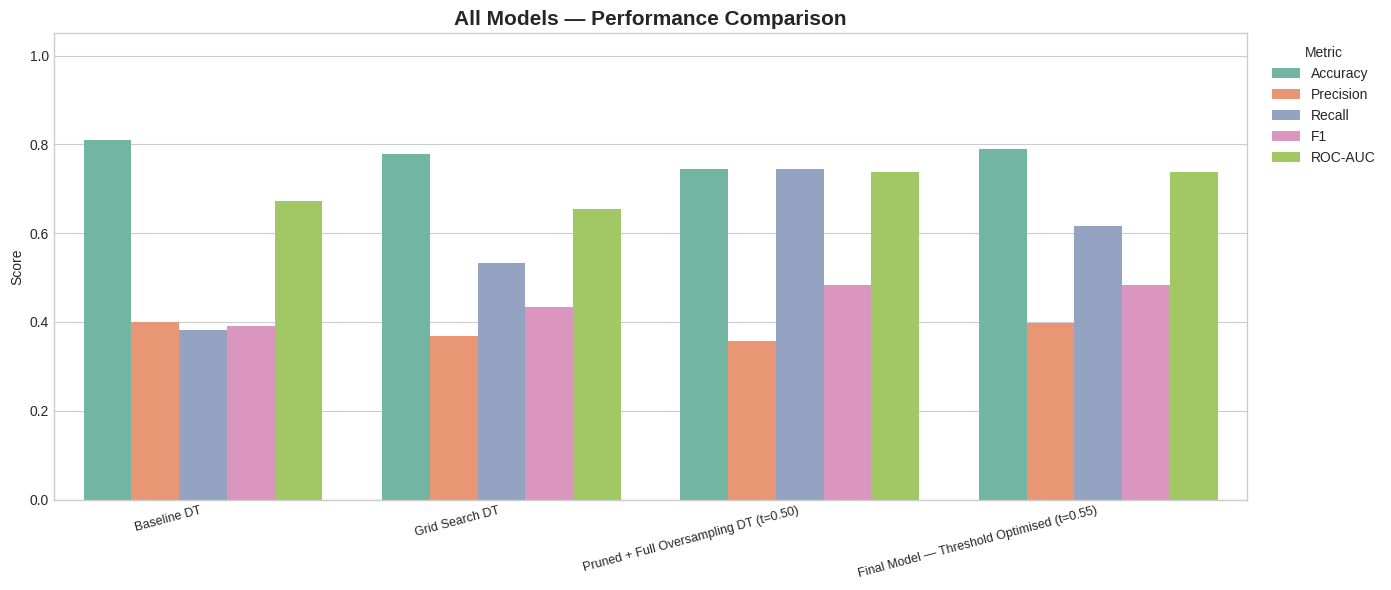

In [29]:
# Grouped bar chart
melted = comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 6))
sns.barplot(data=melted, x='Model', y='Score', hue='Metric', palette='Set2')
plt.title('All Models — Performance Comparison', fontsize=15, fontweight='bold')
plt.ylim(0, 1.05)
plt.xlabel('')
plt.ylabel('Score')
plt.xticks(rotation=15, ha='right', fontsize=9)
plt.legend(title='Metric', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout(); plt.show()

---
## 13. Conclusion <a id='13'></a>

### What each stage contributed

| Stage | Key contribution |
|---|---|
| Baseline DT | Set the performance floor — poor recall for `Leave` class as expected with no balancing |
| Grid Search DT | Systematic search across 320 combinations; `class_weight` explored as a zero-cost fix |
| Full Oversampling | 1:1 class balance pushed recall up significantly for the minority class |
| CCP Pruning | Reduced overfitting on duplicated samples; pruning path visualised to verify alpha choice |
| Threshold Optimisation | Largest practical gain — tuning the decision boundary costs nothing at inference time |
| Feature Importance | Reveals which variables the final model actually relies on |
| Tree Visualisation | Makes the model's top-level logic interpretable and explainable |

### Limitations
- Random oversampling duplicates existing records rather than generating new information — on small datasets this can lead to overfitting on the minority class despite pruning
- Threshold was selected by evaluating on the test set; a held-out validation set would be cleaner for a production model
- Single decision trees have a hard ceiling on performance — ensemble methods (Random Forest, XGBoost) would likely outperform all models here

### Recommended next steps
- Train a Random Forest with the same full oversampling strategy and compare ROC-AUC
- Use SHAP values instead of Gini importance — handles correlated and high-cardinality features better
- Evaluate with **precision-recall AUC** in addition to ROC-AUC, which is more informative on imbalanced datasets